# Генерация начальных координат фотонов

Ноутбук моделирует начальные координаты фотонов в осесимметричном пучке с профилем
$p(r)=\exp(-(r / \sqrt{2a})^2)$ и строит полный набор проверочных графиков.

In [2]:
from photon_beam import (
    auto_tune_simulation,
    format_fit_result,
    plot_a_comparison,
    plot_results,
    sample_photon_positions,
    save_positions,
    summarize_sample,
)

import numpy as np

N = 10_000
a = 4.0
seed = 42

In [3]:
fit_result = auto_tune_simulation(
    a=a,
    error_tolerance=0.05,
    target='axis_section',
    metric='relative_l2',
    seed=seed,
    n_trials=5,
)
print(format_fit_result(fit_result, 0.05))
N = fit_result.n_photons
bins = fit_result.bins

Автоподбор параметров моделирования
target = axis_section
metric = relative_l2
seeds = [42, 43, 44, 45, 46]
criterion = mean_error <= tolerance и max_error <= tolerance
N = 50000
bins = 40
mean_error = 3.372417e-02
max_error = 4.326637e-02
tolerance = 5.000000e-02
Порог достигнут: да


In [4]:
rng = np.random.default_rng(seed)
sample = sample_photon_positions(N, a, rng=rng)
save_positions(sample, output_path='photon_positions.csv')
print(summarize_sample(sample, a))

N = 50000
a = 4.0
Средний радиус: 2.509760 (теория: 2.506628)
Среднее по x: -0.002725 (теория: 0.000000)
СКО по x: 2.001395 (теория: 2.000000)


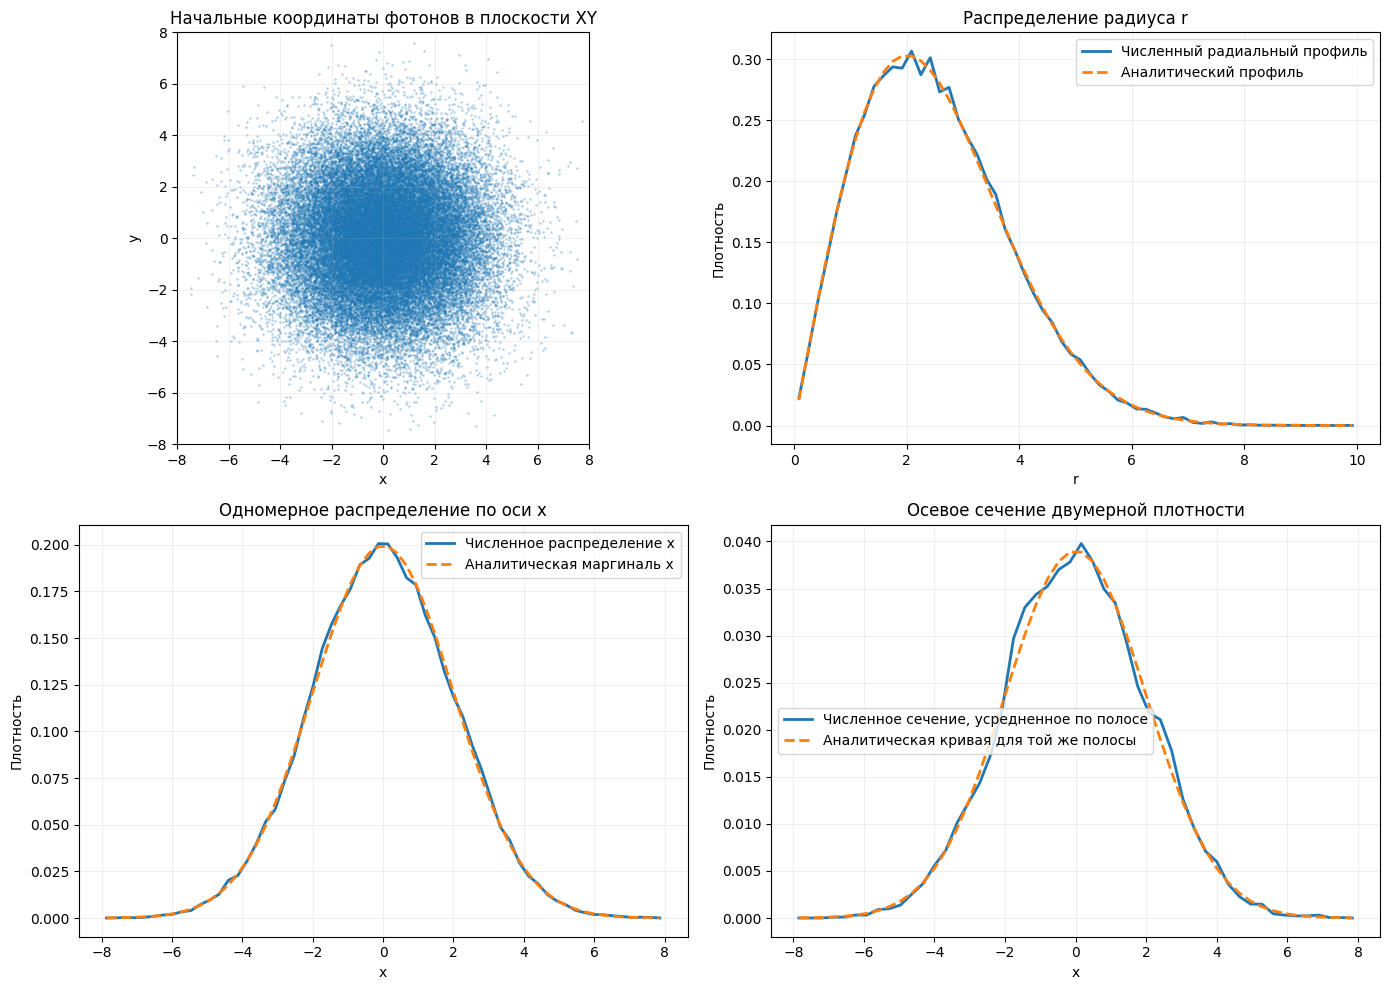

In [5]:
fig, axes = plot_results(sample, a=a, bins=bins)

## Что сравнивается с аналитикой

- Радиальное распределение `r`
- Одномерное распределение координаты `x`
- Осевое сечение двумерной плотности `rho(x, 0)`